# RC4の統計的有意性に関するカイ二乗検定

このノートブックはRC4によって生成されたキーストリームの分布が一様分布と統計的に異なるのかを検証するために，カイ二乗分布を実行します．

カイ二乗分布により，以下の点を判断します．
- 観察された偏りが統計的に有意なのか，それとも単なるランダムなノイズなのかを判断します． 
- 各バイトの位置で 一様分布からどれくらい逸脱するのか 
- どの位置のバイトが最も攻撃に弱いのか 

## Step 1: ライブラリをインポートして，キーストリームの関数を宣言します．

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats


In [12]:
def get_keystream_bytes(key_bytes, n_bytes):
    """
    与えられた鍵から鍵ストリームを生成する関数
    
    この関数ではRC4の完全なアルゴリズムを作成する
    1. KSA (Key Scheduling Algorithm): 初期状態ベクトルSを生成 
    2. PRGA (Pseudo-Random Generation Algorithm): キーストリームのバイトを生成する
    
    引数:
        key_bytes: 整数リスト（0-255）として指定された秘密鍵 
        n_bytes: 生成する鍵ストリームのバイト数 
    
    返り値:
        keystream: 鍵ストリームバイトのリスト 
    """
    # === KSA (Key Scheduling Algorithm) ===
    # 状態ベクトルSを整数値[0, 1, 2 ..., 255]で初期化
    state = list(range(256))
    
    j = 0  # KSAで利用されるインデックス変数 
    
    # KSAを実行：キーバイトを混ぜ合わせる
    for i in range(256):
        # 現在の状態と鍵バイトからjを更新する
        j = (j + state[i] + key_bytes[i % len(key_bytes)]) % 256
        
        # S[i]とS[j]の値を交換する（スワップ）
        state[i], state[j] = state[j], state[i]

    # === PRGA (Pseudo-Random Generation Algorithm) ===
    # 実際の鍵ストリームバイトを生成する
    i = 0  # 最初のインデックス変数
    j = 0  # 二番目のインデックス変数 
    keystream = []
    
    # n_bytes分の鍵ストリームを生成
    for _ in range(n_bytes):
        # インデックスを更新する 
        i = (i + 1) % 256
        j = (j + state[i]) % 256
        
        # S[i]とS[j]の値を交換（スワップ）
        state[i], state[j] = state[j], state[i]
        
        # 出力バイトのインデックスを計算
        t = (state[i] + state[j]) % 256
        
        # 生成されたバイトを鍵ストリームに追加
        keystream.append(state[t])
    
    return keystream

# 関数を試してみよう！ 
test_key = [ord(c) for c in 'TestKey']
test_stream = get_keystream_bytes(test_key, 5)
print(f'テスト：鍵ストリームを生成: {test_stream}')

テスト：鍵ストリームを生成: [102, 118, 53, 212, 66]


## Step 2: カイ二乗分布のテスト関数を定義

In [13]:
def perform_chi_square_test(observed_counts, expected_count, byte_position_name):
    """
    カイ二乗適合度検定を実行する関数
    
    カイ二乗検定の定義:
    H0 (帰無仮説): RC4の出力は一様分布に従う（偏りがない）
    H1 (対立仮説): RC4の出力は一様分布に従わない（偏りがある）
    
    p値 < 0.05 の場合、H0を棄却し、統計的な偏りが存在すると結論付ける
    
    引数:
        observed_counts: 各バイト値 (0-255) の観測頻度
        expected_count: 一様分布である場合の期待頻度
        byte_position_name: バイト位置のラベル (例: 'Byte 1')
    
    返り値:
        chi_square: カイ二乗検定統計量
        p_value: 検定のp値
        is_significant: 統計的に有意な偏りがあるかどうかの真偽値
    """
    # 以下の公式を用いてカイ二乗統計量を計算する:
    # χ² = Σ [(観測値 - 期待値)² / 期待値]
    # この値が高いほど、一様分布からの乖離が大きいことを示す
    chi_square = np.sum(((observed_counts - expected_count) ** 2) / expected_count)
    
    # 自由度 = カテゴリ数 - 1
    # 256種類のバイト値があるため、自由度 df = 255
    degrees_of_freedom = 255
    
    # カイ二乗累積分布関数 (CDF) を用いてp値を計算する
    # p値 = P(χ² >= 実際に観測されたカイ二乗値)
    # p値が小さいほど、帰無仮説が正しい確率が低い（＝偏りがある可能性が高い）ことを示す
    p_value = 1 - stats.chi2.cdf(chi_square, degrees_of_freedom)
    
    # 有意水準 (alpha) = 0.05
    # p値 < 0.05 の場合、帰無仮説を棄却し、偏りが存在すると判断する
    is_significant = p_value < 0.001
    
    return chi_square, p_value, is_significant

print('カイ二乗検定関数が正常に定義されました')

カイ二乗検定関数が正常に定義されました


## Step 3: RC4キーストリームの生成とバイト出現頻度の集計

In [14]:
# シミュレーションの反復回数を設定
# 回数が多いほど統計的な信頼性は高まりますが、処理時間は長くなります
iterations = 1_000_000
print(f'{iterations:,} 回のシミュレーションを開始します...\n')

# 各バイト位置の頻度カウンターを初期化
# これらの配列は、各バイト値 (0-255) が出現した回数をカウントします
first_byte_counts = np.zeros(256, dtype=int)
second_byte_counts = np.zeros(256, dtype=int)
third_byte_counts = np.zeros(256, dtype=int)

# シミュレーションを実行
# 注意: 簡略化されたWEP攻撃のシナリオを使用しています:
# - ランダムなIV (3バイト) + 固定の秘密鍵
# - これにより、異なるIVを用いて複数のパケットを暗号化する状況をシミュレートします
for iteration in range(iterations):
    # この反復で使用するランダムなIV (3バイト) を生成
    random_iv = np.random.randint(0, 256, size=3).tolist()
    
    # 固定の秘密鍵 (WEPにおける静的な共通鍵をシミュレート)
    fixed_key = [ord(c) for c in 'SecretKey']
    
    # IVと鍵を結合して完全な鍵を作成
    full_key = random_iv + fixed_key
    
    # 鍵ストリームの最初の3バイトを生成
    stream = get_keystream_bytes(full_key, 3)
    
    # 各バイト値の出現回数をカウント
    first_byte_counts[stream[0]] += 1
    second_byte_counts[stream[1]] += 1
    third_byte_counts[stream[2]] += 1
    
    # 200,000回ごとに進捗を表示
    if (iteration + 1) % 200_000 == 0:
        print(f'  進捗: {iteration + 1:,} / {iterations:,} 回完了')

# 一様分布における期待頻度を計算
# 完全に一様であれば、256種類の各値はすべて同じ回数だけ出現します
expected_count = iterations / 256

print(f'\nシミュレーション完了！')
print(f'各バイト値の期待頻度: {expected_count:.1f}')

1,000,000 回のシミュレーションを開始します...

  進捗: 200,000 / 1,000,000 回完了
  進捗: 400,000 / 1,000,000 回完了
  進捗: 600,000 / 1,000,000 回完了
  進捗: 800,000 / 1,000,000 回完了
  進捗: 1,000,000 / 1,000,000 回完了

シミュレーション完了！
各バイト値の期待頻度: 3906.2


## Step 4: カイ二乗検定を実行 

In [15]:
# 後で分析するためにテスト結果を保存
results = []

print('\n' + '=' * 70)
print('カイ二乗検定の結果')
print('=' * 70)

# 各バイト位置に対してカイ二乗検定を実行
for byte_pos, counts in [
    ('バイト 1 (1番目)', first_byte_counts),
    ('バイト 2 (2番目)', second_byte_counts),
    ('バイト 3 (3番目)', third_byte_counts),
]:
    # カイ二乗検定を実行
    chi_square, p_value, is_significant = perform_chi_square_test(
        counts, expected_count, byte_pos
    )
    
    # 結果を保存
    results.append((byte_pos, chi_square, p_value, is_significant))
    
    # 表示用のラベルを事前に定義（print文の中での条件分岐を回避）
    sig_label = '有意（帰無仮説を棄却）' if is_significant else '有意ではない（帰無仮説を採択）'
    conclusion = '【偏りを検出】' if is_significant else '有意な偏りはなし'
    
    # 結果を表示
    print(f'シード値を設定していないので，毎回実行するごとに出力値が変わります')
    print(f'\n[{byte_pos}]')
    print(f'  カイ二乗統計量: {chi_square:.2f}')
    print(f'  p値: {p_value:.2e}')
    print(f'  有意性 (α=0.001): {sig_label}')
    print(f'  結論: {conclusion}')


カイ二乗検定の結果
シード値を設定していないので，毎回実行するごとに出力値が変わります

[バイト 1 (1番目)]
  カイ二乗統計量: 408.48
  p値: 3.29e-09
  有意性 (α=0.001): 有意（帰無仮説を棄却）
  結論: 【偏りを検出】
シード値を設定していないので，毎回実行するごとに出力値が変わります

[バイト 2 (2番目)]
  カイ二乗統計量: 4075.28
  p値: 0.00e+00
  有意性 (α=0.001): 有意（帰無仮説を棄却）
  結論: 【偏りを検出】
シード値を設定していないので，毎回実行するごとに出力値が変わります

[バイト 3 (3番目)]
  カイ二乗統計量: 294.06
  p値: 4.67e-02
  有意性 (α=0.001): 有意ではない（帰無仮説を採択）
  結論: 有意な偏りはなし


おそらく，ここで1, 2バイト目の結果は偏りを検出したと思う．

カイ二乗統計量が大き大きすぎることから2バイト目は確実に偏りがある

1バイト目は2バイト目ほど顕著ではないけど偏りが存在するようです．

調べてみると，
1. KSAが終わった直後の $state[1]$ と $state[state[1]]$ の値を使って1バイト目が出力されます．
1. RC4のKSAは256回ループしますが，これは数学的には「すべての置換パターンを一様に作り出す」には不十分であることが証明されています．
1. 秘密鍵の最初のバイトが $state[1]$ の入れ替えに直接関与するため，鍵の情報が十分に拡散（Diffusion）されないまま出力 $t$ に反映されてしまうのです．
(Geminiの回答)
だそうです．

## Step 5: カイ二乗検定の結果を可視化 

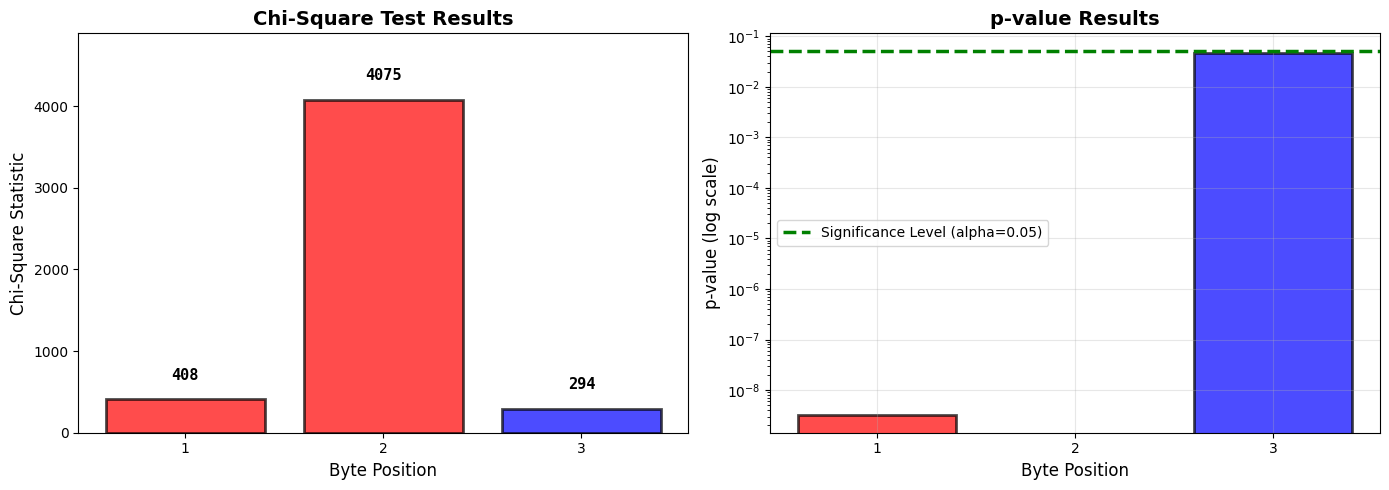


Visualization displayed


In [16]:
# グラフ描画用のデータを抽出
byte_positions = [r[0] for r in results]
chi_squares = [r[1] for r in results]
p_values = [r[2] for r in results]

# 2つのサブプロットを持つ図を作成
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 色分け：赤=有意な偏り、青=有意な偏りなし
colors = ['red' if r[3] else 'blue' for r in results]

# 左のプロット：カイ二乗統計量
ax1.bar(byte_positions, chi_squares, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax1.set_ylabel('Chi-Square Statistic', fontsize=12)
ax1.set_xlabel('Byte Position', fontsize=12)
ax1.set_title('Chi-Square Test Results', fontsize=14, fontweight='bold')
ax1.set_ylim([0, max(chi_squares) * 1.2])

ax1.set_xticks([0, 1, 2])
ax1.set_xticklabels(['1', '2', '3'])

# 棒グラフの上に値をラベルとして追加
# フォント問題を完全に回避するため、数字のみで表示
for i, (pos, val) in enumerate(zip(byte_positions, chi_squares)):
    # 値を数字のみでフォーマット
    label_text = '{:.0f}'.format(val)
    # monospaceフォントとUnicodeマイナス無効化で最大限確実に表示
    ax1.text(i, val + (max(chi_squares) * 0.05), label_text, ha='center', va='bottom',
             fontweight='bold', fontsize=11, family='monospace', usetex=False)

# 右のプロット：p値
ax2.bar(byte_positions, p_values, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax2.axhline(y=0.05, color='green', linestyle='--', linewidth=2.5, label='Significance Level (alpha=0.05)')
ax2.set_ylabel('p-value (log scale)', fontsize=12)
ax2.set_xlabel('Byte Position', fontsize=12)
ax2.set_yscale('log')
ax2.set_title('p-value Results', fontsize=14, fontweight='bold')
ax2.set_xticks([0, 1, 2])
ax2.set_xticklabels(['1', '2', '3'])
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('\nVisualization displayed')

## Step 6: バイト値の分布について分析 

In [17]:
# 各バイト位置の分布を詳細に分析
print('\n' + '=' * 70)
print('詳細分析: バイト値の偏り（バイアス）')
print('=' * 70)

for byte_pos, counts in [
    ('バイト 1', first_byte_counts),
    ('バイト 2', second_byte_counts),
    ('バイト 3', third_byte_counts),
]:
    print(f'\n{byte_pos} - 偏り分析')
    print('-' * 60)
    
    # 期待される頻度からの偏差を計算
    # 正の偏差 = 期待値より多く出現
    # 負の偏差 = 期待値より少なく出現
    differences = counts - expected_count
    
    # 相対偏差をパーセンテージとして計算
    # これにより、異なるスケール間での比較が容易になります
    relative_deviations = (differences / expected_count) * 100
    
    # 出現頻度が高いものと低いもののインデックスを取得
    # これらが最も偏りの強い値になります
    top_indices = np.argsort(relative_deviations)[-5:][::-1]
    bottom_indices = np.argsort(relative_deviations)[:5]
    
    print('\n出現頻度が高い値（トップ5）:')
    print('  値   |  観測頻度 |   期待値 |    偏差   | 偏差(%)')
    print('  -----|-----------|----------|-----------|-------------')
    for idx in top_indices:
        print(f'  {idx:3d}  | {counts[idx]:9.0f} | {expected_count:8.1f} | +{differences[idx]:7.0f} | +{relative_deviations[idx]:5.2f}%')
    
    print('\n出現頻度が低い値（ワースト5）:')
    print('  値   |  観測頻度 |   期待値 |    偏差   | 偏差(%)')
    print('  -----|-----------|----------|-----------|-------------')
    for idx in bottom_indices:
        print(f'  {idx:3d}  | {counts[idx]:9.0f} | {expected_count:8.1f} | {differences[idx]:7.0f} | {relative_deviations[idx]:5.2f}%')


詳細分析: バイト値の偏り（バイアス）

バイト 1 - 偏り分析
------------------------------------------------------------

出現頻度が高い値（トップ5）:
  値   |  観測頻度 |   期待値 |    偏差   | 偏差(%)
  -----|-----------|----------|-----------|-------------
  160  |      4252 |   3906.2 | +    346 | + 8.85%
   50  |      4189 |   3906.2 | +    283 | + 7.24%
   42  |      4141 |   3906.2 | +    235 | + 6.01%
    9  |      4108 |   3906.2 | +    202 | + 5.16%
   93  |      4103 |   3906.2 | +    197 | + 5.04%

出現頻度が低い値（ワースト5）:
  値   |  観測頻度 |   期待値 |    偏差   | 偏差(%)
  -----|-----------|----------|-----------|-------------
  113  |      3659 |   3906.2 |    -247 | -6.33%
   18  |      3733 |   3906.2 |    -173 | -4.44%
   76  |      3738 |   3906.2 |    -168 | -4.31%
   53  |      3762 |   3906.2 |    -144 | -3.69%
  158  |      3773 |   3906.2 |    -133 | -3.41%

バイト 2 - 偏り分析
------------------------------------------------------------

出現頻度が高い値（トップ5）:
  値   |  観測頻度 |   期待値 |    偏差   | 偏差(%)
  -----|-----------|----------|-----------|

## Step 7: KLダイバージェンスを計算 

In [18]:
# 各バイト位置におけるKullback-Leibler情報量（KLダイバージェンス）を計算
# KLダイバージェンスは、観測された分布が一様分布とどれだけ異なっているかを測定する
print('\n' + '=' * 70)
print('KLダイバージェンス分析')
print('=' * 70)
print('\nKL(観測値 || 一様分布) は、観測された分布と一様分布の間の')
print('「情報の距離」を測定します。')
print('0に近いほど、より一様（理想的なランダム）に近いことを示します。')
print('\n分析結果:')

for byte_pos, counts in [
    ('バイト 1', first_byte_counts),
    ('バイト 2', second_byte_counts),
    ('バイト 3', third_byte_counts),
]:
    # 出現回数を確率（出現確率）に変換
    observed_probs = counts / iterations
    
    # 一様分布の確率（理想的なランダムの理論値）
    uniform_probs = np.ones(256) / 256
    
    # KLダイバージェンスを計算
    # 公式: KL(P||Q) = Σ P(x) * log(P(x) / Q(x))
    # log(0) によるエラーを避けるため、微小な値（エプシロン）を加算
    kl_divergence = np.sum(observed_probs * np.log(observed_probs / uniform_probs + 1e-10))
    
    print(f'\n{byte_pos}')
    print(f'  KLダイバージェンス: {kl_divergence:.8f}')


KLダイバージェンス分析

KL(観測値 || 一様分布) は、観測された分布と一様分布の間の
「情報の距離」を測定します。
0に近いほど、より一様（理想的なランダム）に近いことを示します。

分析結果:

バイト 1
  KLダイバージェンス: 0.00020344

バイト 2
  KLダイバージェンス: 0.00161309

バイト 3
  KLダイバージェンス: 0.00014712


## Step 8: 結論 

In [ ]:
# 統計検定から結論を導き出す
print('\n' + '=' * 70)
print('結論')
print('=' * 70)

# 有意な偏りが見つかったバイト位置を特定
significant_bytes = [r[0] for r in results if r[3]]

if significant_bytes:
    print(f'\n統計的に「有意な偏り」が検出されたバイト位置:')
    print(f'  {", ".join(significant_bytes)}')
    print('\n考察:')
    print('これらのバイト位置では、偶然に発生するとは極めて考えにくい')
    print('一様ではない分布（偏り）が示されています (p値 < 0.001)。')
    print('\nセキュリティ上の影響 (Security Implication):')
    print('攻撃者は、以下のような手法でこの偏りを悪用する可能性があります:')
    print('- FMS攻撃: 秘密鍵と鍵ストリームの間の相関を利用する')
    print('- 統計的攻撃: 大量の暗号文を解析する')
    print('- WEPクラック: 暗号化されたパケットから秘密鍵を復元する')
    print('\nこれが、RC4が現在は暗号学的に「脆弱（broken）」とみなされ、')
    print('公式に非推奨（deprecated）となっている理由です。')
else:
    print('\n統計的に有意な偏りは検出されませんでした。')
    print('すべてのバイト位置において、分布は一様であると考えられます。')


結論

統計的に「有意な偏り」が検出されたバイト位置:
  バイト 1 (1番目), バイト 2 (2番目)

考察:
これらのバイト位置では、偶然に発生するとは極めて考えにくい
一様ではない分布（偏り）が示されています (p値 < 0.05)。

セキュリティ上の影響 (Security Implication):
攻撃者は、以下のような手法でこの偏りを悪用する可能性があります:
- FMS攻撃: 秘密鍵と鍵ストリームの間の相関を利用する
- 統計的攻撃: 大量の暗号文を解析する
- WEPクラック: 暗号化されたパケットから秘密鍵を復元する

これが、RC4が現在は暗号学的に「脆弱（broken）」とみなされ、
公式に非推奨（deprecated）となっている理由です。
